# Doo — XGBoost 모델

고객 이탈 예측을 위한 XGBoost 분류 모델입니다.

- Train 데이터로만 모델을 학습합니다.
- Validation 데이터로 성능과 임계값을 비교합니다.
- Test 데이터는 최종 모델 확정 전까지 사용하지 않습니다.
- 팀 공통 시드 `random_state=42`를 사용합니다.

## 0. 실행 환경

`ModuleNotFoundError: No module named 'xgboost'`가 발생하면 현재 노트북 커널에 `%pip install xgboost`를 한 번 실행한 뒤 커널을 재시작합니다. 팀 프로젝트에서는 설치 후 `requirements.txt` 반영 여부를 팀원들과 합의해야 합니다.

In [18]:
from pathlib import Path
import pickle

import pandas as pd
import xgboost

from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "preprocessed").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

print("XGBoost version:", xgboost.__version__)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

XGBoost version: 3.3.0
X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1. 데이터 확인

피처, 자료형, 결측치와 타깃 분포를 확인합니다.

In [19]:
display(X_train.head())
display(pd.DataFrame({
    "dtype": X_train.dtypes,
    "train_missing": X_train.isna().sum(),
    "val_missing": X_val.isna().sum(),
}))
display(y_train.value_counts().rename_axis("churn").to_frame("count"))

,net_revenue,recency_days,frequency,distinct_products,tenure_days,avg_days_between_orders,is_low_value,is_uk,has_return,recent_activity_ratio
0,-0.671757,1.614952,-0.407252,-0.671793,-0.406069,0.616805,0.0,1.0,1.0,0.0
1,-0.965400,-0.314654,-0.475206,-0.745705,-1.605762,-0.078723,0.0,1.0,0.0,0.0
2,-1.073778,0.274474,-0.475206,-0.736466,-1.245854,0.695333,0.0,1.0,0.0,0.0
3,-0.542093,-1.091619,-0.475206,-0.440820,-2.080423,-1.099580,0.0,1.0,0.0,1.0
4,-0.942516,0.641611,-0.407252,-0.487015,-0.473878,0.543887,1.0,1.0,0.0,0.0


,dtype,train_missing,val_missing
net_revenue,float64,0,0
recency_days,float64,0,0
frequency,float64,0,0
distinct_products,float64,0,0
tenure_days,float64,0,0
avg_days_between_orders,float64,0,0
is_low_value,float64,0,0
is_uk,float64,0,0
has_return,float64,0,0
recent_activity_ratio,float64,0,0


,count
churn,
0,1312
1,1280


## 2. 모델 학습

작은 정형 데이터에서 과적합을 줄이도록 트리 깊이, 학습률, 샘플링과 규제를 설정합니다. `eval_set`은 Train과 Validation의 logloss 변화를 기록하기 위한 용도입니다.

In [20]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgboost_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
print("학습 완료")

학습 완료


## 3. Validation 기본 성능

기본 분류 임계값 0.5에서 Train과 Validation 성능 차이 및 주요 분류 지표를 확인합니다.

In [21]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)

xgboost_train_pred = xgboost_model.predict(X_train)
xgboost_val_pred = xgboost_model.predict(X_val)
xgboost_val_proba = xgboost_model.predict_proba(X_val)[:, 1]

xgboost_metrics_05 = pd.Series({
    "train_accuracy": accuracy_score(y_train, xgboost_train_pred),
    "val_accuracy": accuracy_score(y_val, xgboost_val_pred),
    "recall": recall_score(y_val, xgboost_val_pred),
    "precision": precision_score(y_val, xgboost_val_pred),
    "f1": f1_score(y_val, xgboost_val_pred),
    "roc_auc": roc_auc_score(y_val, xgboost_val_proba),
}, name="threshold_0.50")

display(xgboost_metrics_05.to_frame())
print("Confusion matrix")
print(confusion_matrix(y_val, xgboost_val_pred))
print("\nClassification report")
print(classification_report(y_val, xgboost_val_pred, digits=3))

,threshold_0.50
train_accuracy,0.756173
val_accuracy,0.706019
recall,0.730679
precision,0.691796
f1,0.710706
roc_auc,0.764377


Confusion matrix
[[298 139]
 [115 312]]

Classification report
              precision    recall  f1-score   support

           0      0.722     0.682     0.701       437
           1      0.692     0.731     0.711       427

    accuracy                          0.706       864
   macro avg      0.707     0.706     0.706       864
weighted avg      0.707     0.706     0.706       864



## 4. 임계값 비교

Validation 데이터에서 Recall, Precision, F1-score와 이탈 예측 고객 수를 비교합니다.

In [22]:
xgboost_threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    xgboost_threshold_pred = (xgboost_val_proba >= threshold).astype(int)
    xgboost_threshold_results.append({
        "threshold": threshold,
        "recall": recall_score(y_val, xgboost_threshold_pred),
        "precision": precision_score(y_val, xgboost_threshold_pred, zero_division=0),
        "f1": f1_score(y_val, xgboost_threshold_pred, zero_division=0),
        "predicted_churn_count": int(xgboost_threshold_pred.sum()),
    })

xgboost_threshold_df = pd.DataFrame(xgboost_threshold_results)
display(xgboost_threshold_df.style.format({
    "threshold": "{:.2f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}",
}))

,threshold,recall,precision,f1,predicted_churn_count
0,0.30,0.902,0.616,0.732,625
1,0.35,0.871,0.635,0.734,586
2,0.40,0.829,0.651,0.729,544
3,0.45,0.780,0.673,0.722,495
4,0.50,0.731,0.692,0.711,451
5,0.55,0.660,0.703,0.681,401
6,0.60,0.571,0.718,0.636,340
7,0.65,0.480,0.735,0.581,279
8,0.70,0.365,0.761,0.494,205


## 5. 학습 로그

Boosting round가 증가할 때 Train과 Validation logloss가 어떻게 변하는지 확인합니다. 두 값의 차이가 계속 커지면 과적합 가능성을 의심할 수 있습니다.

In [23]:
xgboost_evaluation_log = xgboost_model.evals_result()
xgboost_log_df = pd.DataFrame({
    "round": range(len(xgboost_evaluation_log["validation_0"]["logloss"])),
    "train_logloss": xgboost_evaluation_log["validation_0"]["logloss"],
    "val_logloss": xgboost_evaluation_log["validation_1"]["logloss"],
})
display(pd.concat([xgboost_log_df.head(3), xgboost_log_df.tail(3)]))

,round,train_logloss,val_logloss
0,0,0.686384,0.687193
1,1,0.679876,0.681348
2,2,0.673959,0.676090
297,297,0.495716,0.579261
298,298,0.495548,0.579185
299,299,0.495462,0.579154


## 6. 피처 중요도

XGBoost가 예측 분할에 사용한 피처 중요도를 확인합니다. 중요도는 인과관계를 의미하지 않습니다.

In [24]:
xgboost_importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgboost_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(xgboost_importance_df)

,feature,importance
0,avg_days_between_orders,0.306846
1,net_revenue,0.119634
2,recency_days,0.103987
3,frequency,0.101183
4,is_low_value,0.084221
5,distinct_products,0.082019
6,recent_activity_ratio,0.074314
7,tenure_days,0.058583
8,has_return,0.045384
9,is_uk,0.023829


## 7. 혼동행렬 시각화

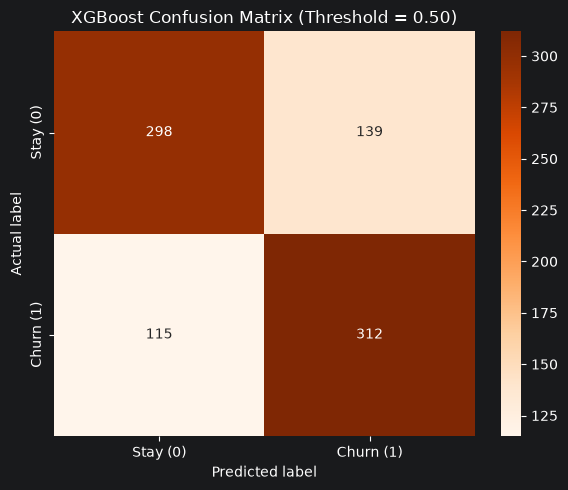

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

xgboost_confusion_matrix = confusion_matrix(y_val, xgboost_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    xgboost_confusion_matrix, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"],
)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("XGBoost Confusion Matrix (Threshold = 0.50)")
plt.tight_layout()
plt.show()

## 8. 임계값별 성능 변화

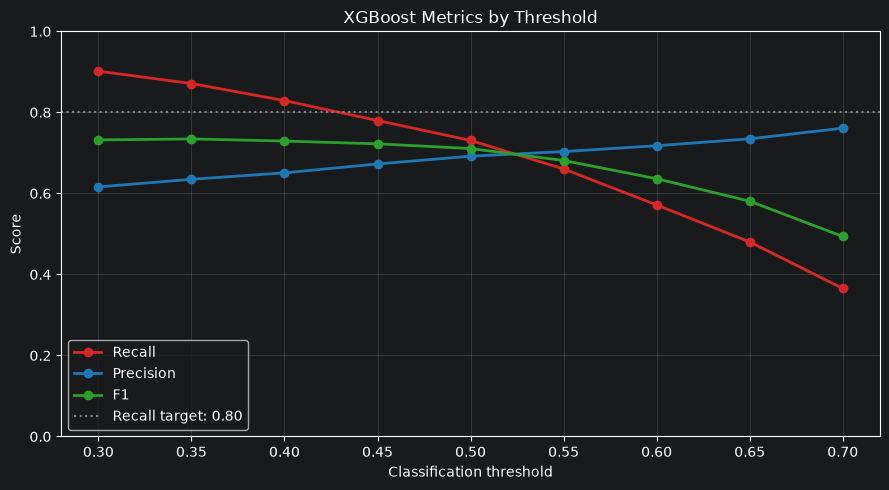

In [26]:
plt.figure(figsize=(9, 5))
for metric, color in [("recall", "tab:red"), ("precision", "tab:blue"), ("f1", "tab:green")]:
    plt.plot(
        xgboost_threshold_df["threshold"], xgboost_threshold_df[metric],
        marker="o", linewidth=2, color=color,
        label=metric.upper() if metric == "f1" else metric.title(),
    )
plt.axhline(0.80, color="gray", linestyle=":", label="Recall target: 0.80")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("XGBoost Metrics by Threshold")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 9. ROC Curve와 Precision–Recall Curve

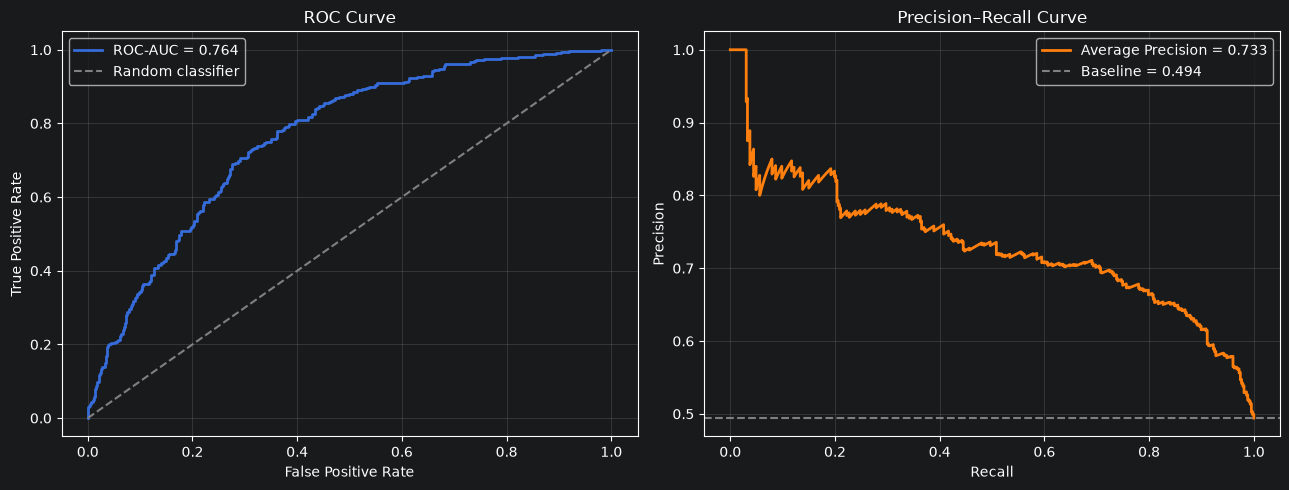

In [27]:
from sklearn.metrics import auc, average_precision_score, precision_recall_curve, roc_curve

xgboost_fpr, xgboost_tpr, _ = roc_curve(y_val, xgboost_val_proba)
xgboost_roc_auc = auc(xgboost_fpr, xgboost_tpr)
xgboost_pr_precision, xgboost_pr_recall, _ = precision_recall_curve(y_val, xgboost_val_proba)
xgboost_average_precision = average_precision_score(y_val, xgboost_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(xgboost_fpr, xgboost_tpr, linewidth=2, label=f"ROC-AUC = {xgboost_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(
    xgboost_pr_recall, xgboost_pr_precision, linewidth=2, color="tab:orange",
    label=f"Average Precision = {xgboost_average_precision:.3f}",
)
axes[1].axhline(y_val.mean(), linestyle="--", color="gray", label=f"Baseline = {y_val.mean():.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. 학습 로그와 피처 중요도 시각화

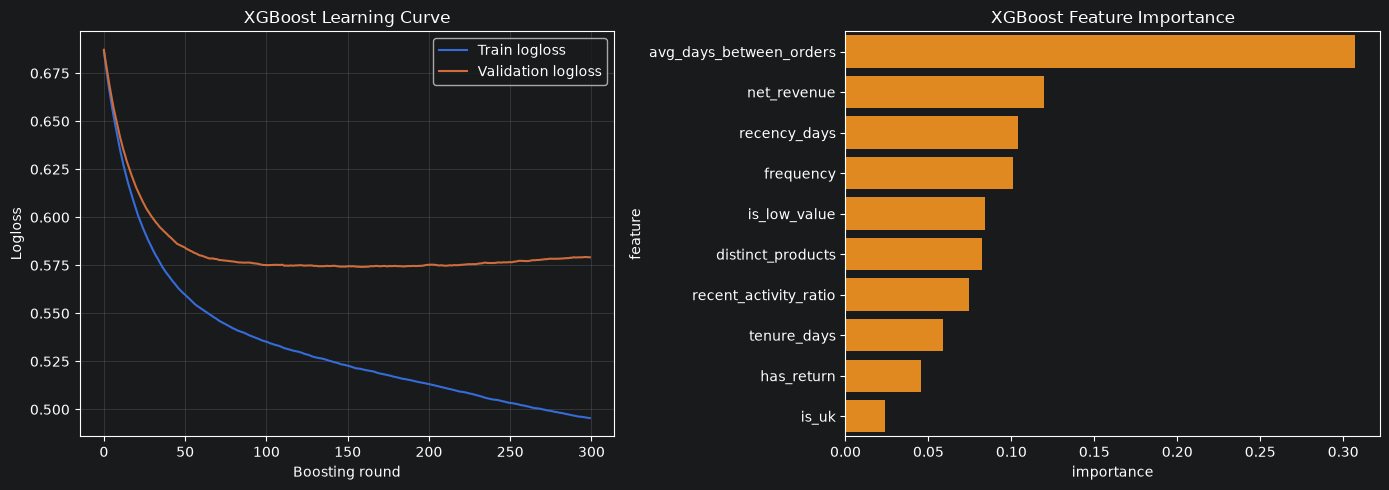

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xgboost_log_df["round"], xgboost_log_df["train_logloss"], label="Train logloss")
axes[0].plot(xgboost_log_df["round"], xgboost_log_df["val_logloss"], label="Validation logloss")
axes[0].set(xlabel="Boosting round", ylabel="Logloss", title="XGBoost Learning Curve")
axes[0].legend()
axes[0].grid(alpha=0.25)
sns.barplot(data=xgboost_importance_df, x="importance", y="feature", color="darkorange", ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## 11. 실험 결과 기록

Recall 0.80 이상 후보 중 F1-score가 가장 높은 임계값을 확인합니다.

In [29]:
xgboost_candidates = xgboost_threshold_df[xgboost_threshold_df["recall"] >= 0.80]
if xgboost_candidates.empty:
    print("Recall 0.80 이상인 임계값 후보가 없습니다.")
else:
    xgboost_best_candidate = xgboost_candidates.loc[xgboost_candidates["f1"].idxmax()]
    display(xgboost_best_candidate.to_frame("selected_value"))

,selected_value
threshold,0.350000
recall,0.871194
precision,0.634812
f1,0.734452
predicted_churn_count,586.000000


## 12. 모델 구성 및 평가 기준 설명

이 노트북은 수업에서 배운 `XGBClassifier`의 **순차적 오류 보완, `eval_set`, logloss 확인, 피처 중요도** 흐름을 고객 이탈 예측 문제에 맞게 확장했다.

### 데이터 사용 원칙

- 팀 공통 Train/Validation 데이터를 사용해 다른 모델과 비교 조건을 통일했다.
- XGBoost는 스케일링이 필수는 아니지만 팀 공통 전처리 데이터를 그대로 사용했다.
- Test 데이터는 최종 모델 확정 후 한 번만 평가하기 위해 불러오지 않았다.

### XGBoost를 사용한 이유

- 이전 트리가 틀린 부분을 다음 트리가 순차적으로 보완하는 Boosting 모델이다.
- 고객 행동의 비선형 관계와 피처 간 상호작용을 학습할 수 있다.
- 확률 예측, 피처 중요도, 학습 로그를 제공해 모델 성능과 과적합을 확인하기 좋다.

### 주요 설정 이유

- 낮은 `learning_rate=0.03`과 `n_estimators=300`을 조합해 각 트리가 조금씩 보완하도록 했다.
- `max_depth=3`, `min_child_weight=5`로 개별 트리의 복잡도를 제한했다.
- `subsample=0.8`, `colsample_bytree=0.8`로 각 트리가 일부 고객과 피처를 사용하게 해 과적합을 줄였다.
- `reg_alpha`, `reg_lambda`로 L1/L2 규제를 적용했다.
- `objective='binary:logistic'`은 `churn=1` 확률을 출력하고, `eval_metric='logloss'`는 확률 예측의 학습 변화를 기록한다.

### 평가 기준

이탈 고객을 놓치지 않기 위해 Recall을 우선하되 Precision과 F1-score도 함께 비교한다. 기본 임계값 외에 여러 임계값을 확인하고, ROC-AUC와 Precision–Recall Curve로 임계값과 무관한 전반적인 분류 능력도 평가한다. 피처 중요도는 예측에 사용된 정도이며 인과관계를 뜻하지 않는다. 최종 선정은 Logistic Regression 및 Random Forest와 동일한 Validation 기준으로 비교해 결정한다.